Notebbok para el entramiento del modelo.

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
import joblib


In [38]:
df = pd.read_csv('../data/processed/df_clean.csv')

In [ ]:
numerical_cols = [
    'Freedom',  
    'Trust (Government Corruption)', 
    'Family', 
    'Economy (GDP per Capita)',
    'Health (Life Expectancy)',
]

categorical_cols_encoded = [col for col in df.columns if col.startswith('Region_')]
target_col = 'Happiness Score'

# Incluir tanto columnas numéricas como categóricas codificadas en X
X = df[numerical_cols + categorical_cols_encoded]
y = df[target_col]


# Dividir en entrenamiento y prueba (70-30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar solo las columnas numéricas
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

# Convertir a DataFrame para mantener los nombres de las columnas
X_train_num_df = pd.DataFrame(X_train_num, columns=numerical_cols, index=X_train.index)
X_test_num_df = pd.DataFrame(X_test_num, columns=numerical_cols, index=X_test.index)

# Seleccionar columnas categóricas codificadas (ya son 0/1, no necesitan transformación)
X_train_cat_df = X_train[categorical_cols_encoded]
X_test_cat_df = X_test[categorical_cols_encoded]

# Combinar columnas numéricas escaladas y categóricas codificadas
X_train_encoded = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_test_encoded = pd.concat([X_test_num_df, X_test_cat_df], axis=1)


In [40]:
#Radom Forest Regressor
model_RFR = RandomForestRegressor(random_state=42)
model_RFR.fit(X_train_encoded, y_train)
y_pred_RFR = model_RFR.predict(X_test_encoded)
mse_RFR = mean_squared_error(y_test, y_pred_RFR)
r2_RFR = r2_score(y_test, y_pred_RFR)
mae_RFR = mean_absolute_error(y_test, y_pred_RFR)
print("Radom Forest Regressor - Metricas")
print(f"\nMean Squared Error: {mse_RFR}")
print(f"R2 Score: {r2_RFR}")
print(f"Mean Absolute Error: {mae_RFR}")

Radom Forest Regressor - Metricas

Mean Squared Error: 0.1757427651195748
R2 Score: 0.8591597158934745
Mean Absolute Error: 0.30651110638297874


In [41]:
# XGBoost
model_XGB = XGBRegressor(random_state=42)
model_XGB.fit(X_train_encoded, y_train)
y_pred_XGB = model_XGB.predict(X_test_encoded)
mse_XGB = mean_squared_error(y_test, y_pred_XGB)
r2_XGB = r2_score(y_test, y_pred_XGB)
mae_XGB = mean_absolute_error(y_test, y_pred_XGB)
print("XCGBoost - Metricas:")
print(f"\nXGBoost Mean Squared Error (MSE): {mse_XGB:.4f}")
print(f"XGBoost R² Score: {r2_XGB:.4f}")
print(f"XGBoost Mean Absolute Error (MAE): {mae_XGB:.4f}")

XCGBoost - Metricas:

XGBoost Mean Squared Error (MSE): 0.1700
XGBoost R² Score: 0.8637
XGBoost Mean Absolute Error (MAE): 0.2761


In [42]:
#Support Vector Regressor
model_SVR = SVR(kernel = "rbf")
model_SVR.fit(X_train_encoded, y_train)
y_pred_SVR = model_SVR.predict(X_test_encoded)
mse_SVR = mean_squared_error(y_test, y_pred_SVR)
r2_SVR = r2_score(y_test, y_pred_SVR)
mae_SVR = mean_absolute_error(y_test, y_pred_SVR)
print("\nSupport Vector Regressor - Métricas:")
print(f"\nSupport Vector Regressor - MSE: {mse_SVR:.4f}")
print(f"Support Vector Regressor - R²: {r2_SVR:.4f}")
print(f"Support Vector Regressor - MAE: {mae_SVR:.4f}")


Support Vector Regressor - Métricas:

Support Vector Regressor - MSE: 0.2011
Support Vector Regressor - R²: 0.8389
Support Vector Regressor - MAE: 0.3326


In [43]:
#k-Nearest Neighbors regressor
model_KNN = KNeighborsRegressor(n_neighbors=5)
model_KNN.fit(X_train_encoded, y_train)
y_pred_KNN = model_KNN.predict(X_test_encoded)
mse_KNN = mean_squared_error(y_test, y_pred_KNN)
r2_KNN = r2_score(y_test, y_pred_KNN)
mae_KNN = mean_absolute_error(y_test, y_pred_KNN)
print("\nk-Nearest Neighbors Regressor - Métricas:")
print(f"\nk-Nearest Neighbors Regressor - MSE: {mse_KNN:.4f}")
print(f"k-Nearest Neighbors Regressor - R²: {r2_KNN:.4f}")
print(f"k-Nearest Neighbors Regressor - MAE: {mae_KNN:.4f}")


k-Nearest Neighbors Regressor - Métricas:

k-Nearest Neighbors Regressor - MSE: 0.2049
k-Nearest Neighbors Regressor - R²: 0.8358
k-Nearest Neighbors Regressor - MAE: 0.3463


In [44]:
# Lasso regression
model_Lasso = Lasso(alpha=0.1, random_state=42)
model_Lasso.fit(X_train_encoded, y_train)
y_pred_Lasso = model_Lasso.predict(X_test_encoded)
mse_Lasso = mean_squared_error(y_test, y_pred_Lasso)
r2_Lasso = r2_score(y_test, y_pred_Lasso)
mae_Lasso = mean_absolute_error(y_test, y_pred_Lasso)
print("\nLasso Regression - Métricas:")
print(f"\nLasso Regression - MSE: {mse_Lasso:.4f}")
print(f"Lasso Regression - R²: {r2_Lasso:.4f}")
print(f"Lasso Regression - MAE: {mae_Lasso:.4f}")


Lasso Regression - Métricas:

Lasso Regression - MSE: 0.3644
Lasso Regression - R²: 0.7079
Lasso Regression - MAE: 0.4739


In [45]:
# GR
model_GR = GradientBoostingRegressor(random_state=42)
model_GR.fit(X_train_encoded, y_train)
y_pred_GR = model_GR.predict(X_test_encoded)
mse_GR = mean_squared_error(y_test, y_pred_GR)
r2_GR = r2_score(y_test, y_pred_GR)
mae_GR = mean_absolute_error(y_test, y_pred_GR)
print("\nGradient Boosting Regressor - Métricas:")
print(f"\nGradient Boosting Regressor - MSE: {mse_GR:.4f}")
print(f"Gradient Boosting Regressor - R²: {r2_GR:.4f}")
print(f"Gradient Boosting Regressor - MAE: {mae_GR:.4f}")


Gradient Boosting Regressor - Métricas:

Gradient Boosting Regressor - MSE: 0.2293
Gradient Boosting Regressor - R²: 0.8162
Gradient Boosting Regressor - MAE: 0.3594


In [46]:
# RMSE
model_RMSE = LinearRegression()
model_RMSE.fit(X_train_encoded, y_train)
y_pred_RMSE = model_RMSE.predict(X_test_encoded)
mse_RMSE = mean_squared_error(y_test, y_pred_RMSE)
r2_RMSE = r2_score(y_test, y_pred_RMSE)
mae_RMSE = mean_absolute_error(y_test, y_pred_RMSE)
print("\nLinear Regression - Métricas:")
print(f"\nLinear Regression - MSE: {mse_RMSE:.4f}")
print(f"Linear Regression - R²: {r2_RMSE:.4f}")
print(f"Linear Regression - MAE: {mae_RMSE:.4f}")


Linear Regression - Métricas:

Linear Regression - MSE: 0.2882
Linear Regression - R²: 0.7690
Linear Regression - MAE: 0.4086


In [47]:
# Importancia de características
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_XGB.feature_importances_
})
print("\nImportancia de características:")
print(feature_importance.sort_values(by='Importance', ascending=False))

()


Importancia de características:
                                   Feature  Importance
7       Region_Latin America and Caribbean    0.297656
2                 Economy (GDP per Capita)    0.187295
3                 Health (Life Expectancy)    0.144686
6                      Region_Eastern Asia    0.115324
5        Region_Central and Eastern Europe    0.079983
11                    Region_Southern Asia    0.036254
0                                  Freedom    0.032236
13                   Region_Western Europe    0.031622
8   Region_Middle East and Northern Africa    0.023197
1            Trust (Government Corruption)    0.021321
10                Region_Southeastern Asia    0.017873
12               Region_Sub-Saharan Africa    0.007906
9                     Region_North America    0.004560
4         Region_Australia and New Zealand    0.000085


()

/tmp/ipykernel_988/2089934645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


TypeError: text() got multiple values for argument 'x'

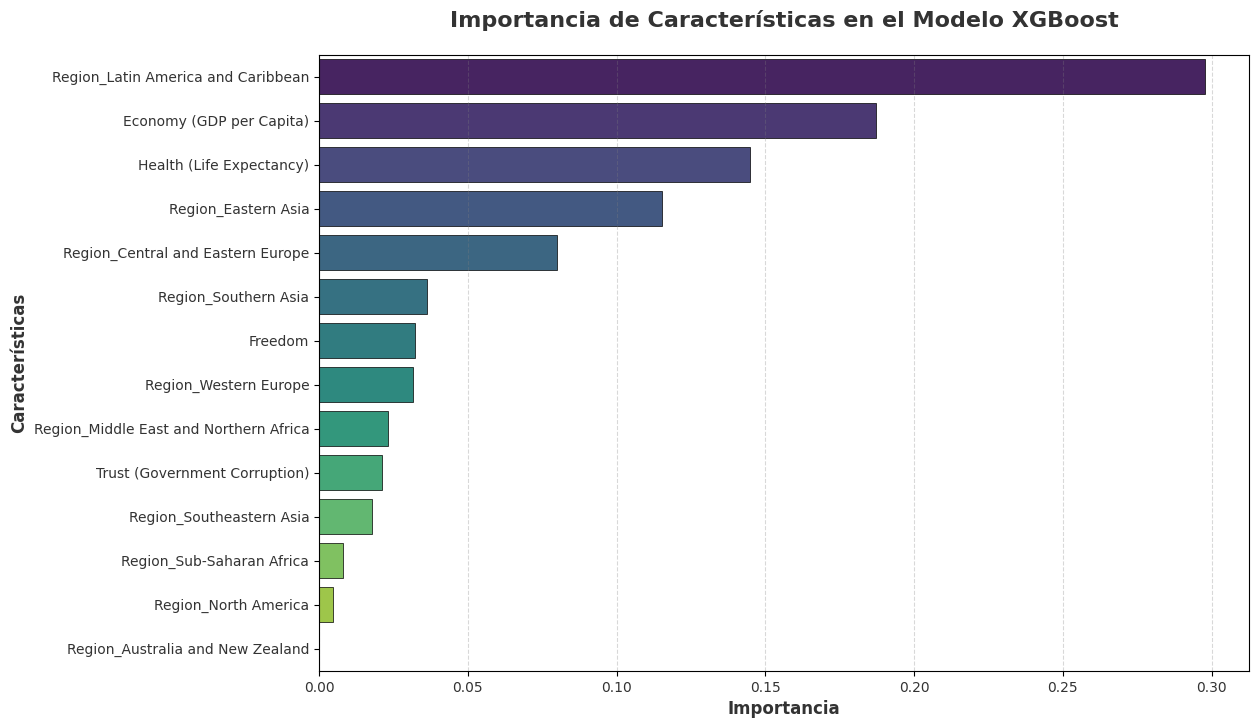

In [48]:
plt.figure(figsize=(12, 8), dpi=100)  # Larger size and higher resolution
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance.sort_values(by='Importance', ascending=False),
    palette='viridis',  # Vibrant, professional color palette
    edgecolor='black',  # Add borders for clarity
    linewidth=0.5
)

# Customize the plot
plt.title('Importancia de Características en el Modelo XGBoost', fontsize=16, weight='bold', pad=20, color='#333333')
plt.xlabel('Importancia', fontsize=12, weight='bold', color='#333333')
plt.ylabel('Características', fontsize=12, weight='bold', color='#333333')
plt.xticks(fontsize=10, color='#333333')
plt.yticks(fontsize=10, color='#333333')

# Add grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.3, color='gray')

# Add value labels on bars
for index, value in enumerate(feature_importance.sort_values(by='Importance', ascending=False)['Importance']):
    plt.text(value, index, f'{value:.3f}', va='center', ha='left', fontsize=9, color='black', x=value+0.002)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

Resumen
Más importantes: Region_Latin America and Caribbean, Economy, Region_Eastern Asia, Health.
Moderadamente importantes: Otras regiones (Central and Eastern Europe, Sub-Saharan Africa).
Menos importantes: Freedom, Family, Trust, Year_, Region_Western Europe, Region_North America.
Implicación: Year_ y algunas regiones (e.g., Australia and New Zealand) podrían excluirse para simplificar el modelo sin perder mucho R².

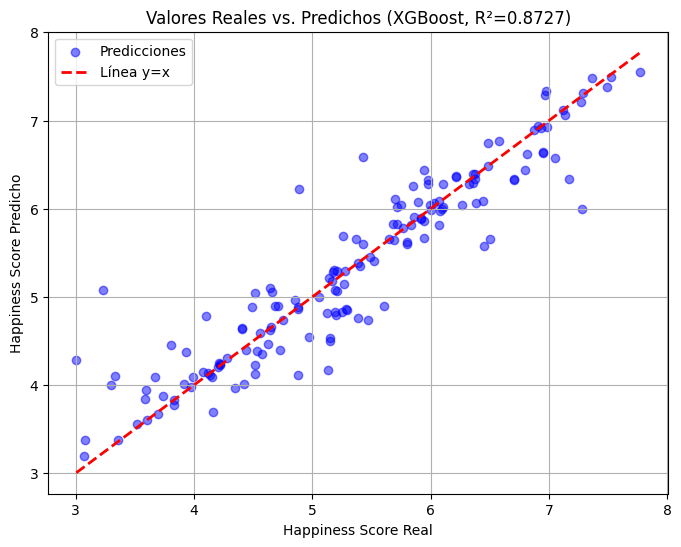

In [ ]:
# Gráfica de dispersión: Valores reales vs. predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_XGB, color='blue', alpha=0.5, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea y=x')
plt.xlabel('Happiness Score Real')
plt.ylabel('Happiness Score Predicho')
plt.title('Valores Reales vs. Predichos (XGBoost, R²={:.4f})'.format(r2_XGB))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}
grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_encoded, y_train)
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor R² (CV):", grid_search.best_score_)

# Evaluar en test
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test_encoded)
print("\nMétricas del mejor modelo:")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Mejor R² (CV): 0.8803513295227244

Métricas del mejor modelo:
MSE: 0.1685
R²: 0.8649
MAE: 0.2646


#Guardar el modelo deseado 

In [ ]:

joblib.dump(model_XGB,'../models/happiness_model_XGB.pkl')  

['../models/happiness_model_XGB.pkl']